In [1]:
# ======================= Objective 2: Affect Projection & Trajectories (RQ2) =======================
# Fresh notebook, end-to-end: Clean → VAD features → Visual "proof" → VAD-only prediction → Lead-time proxy
# Dependencies: numpy, pandas, matplotlib, scikit-learn (no seaborn). No internet access required.

import os, re, glob, json, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, precision_recall_curve, average_precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder

# ------------------------------- Config --------------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED)

DATA_DIR = "/kaggle/input/mentalhealthdata"   # <-- change if needed
PATTERN  = "*.csv"
LOWERCASE_LABELS = True
MAX_SAMPLES = None                             # e.g., 8000 to cap size for quick runs

# Provide NRC VAD CSV for best results (optional). If None / not found, a compact fallback lexicon is used.
VAD_CSV = None  # e.g., "/kaggle/working/NRC-VAD-Lexicon.csv"

# --------------------------- Utility functions -------------------------
def print_header(title):
    bar = "=" * len(title)
    print(f"\n{title}\n{bar}")

def clean_text(s):
    s = str(s)
    s = re.sub(r"\s+", " ", s).strip()
    return "" if s.lower()=="nan" else s

def coerce_datetime(col):
    num = pd.to_numeric(col, errors="coerce")
    dt_from_epoch = pd.to_datetime(num, unit="s", errors="coerce")
    dt_from_str   = pd.to_datetime(col, errors="coerce")
    return dt_from_epoch.fillna(dt_from_str)

def map_file_to_class(files):
    raw = []
    for p in files:
        stem = os.path.splitext(os.path.basename(p))[0]
        token = stem.split("_", 1)[0] if "_" in stem else stem
        raw.append(token.strip().lower() if LOWERCASE_LABELS else token.strip())
    labels, seen = [], {}
    for lab in raw:
        if lab not in seen:
            seen[lab] = 1; labels.append(lab)
        else:
            seen[lab] += 1; labels.append(f"{lab}_{seen[lab]}")
    return labels

def load_and_clean(data_dir=DATA_DIR, pattern=PATTERN, max_samples=MAX_SAMPLES):
    files = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not files:
        raise FileNotFoundError(f"No CSV files in {data_dir} matching {pattern}")
    classes = map_file_to_class(files)

    frames = []
    for p, lab in zip(files, classes):
        df = pd.read_csv(p)
        df.insert(0, "condition_label", lab)
        frames.append(df)

    df = pd.concat(frames, ignore_index=True)

    # Ensure expected columns exist
    keep = ["condition_label","Title","Text","Top_10_Comments","Upvotes","Created_At","Author"]
    for c in keep:
        if c not in df.columns:
            df[c] = np.nan

    for c in ["Title","Text","Top_10_Comments","Author","Created_At"]:
        df[c] = df[c].astype(str).map(clean_text)

    df["created_dt"]     = coerce_datetime(df["Created_At"])
    df["post_only_text"] = (df["Title"] + " " + df["Text"]).map(clean_text).str.lower()
    df["context_text"]   = (df["post_only_text"] + " " + df["Top_10_Comments"]).map(clean_text).str.lower()

    df["token_cnt"] = df["context_text"].str.split().str.len()
    df = df[(df["context_text"]!="") & (df["token_cnt"]>3)].copy()

    df["_dup_key"] = df["context_text"].str.lower()
    df = df.drop_duplicates(subset=["_dup_key"]).drop(columns=["_dup_key"])

    df["Upvotes"] = pd.to_numeric(df["Upvotes"], errors="coerce").astype("Int64")

    if isinstance(max_samples, int) and len(df) > max_samples:
        df = df.sample(max_samples, random_state=SEED).reset_index(drop=True)

    return df.reset_index(drop=True)

# Weak triage labels (bootstrap) — same rules you used in Obj1
kw_crisis = [
    "suicide","kill myself","end my life","want to die","self harm","self-harm",
    "overdose","can't go on","i'm done","ending it","hurt myself","hang myself"
]
kw_red = [
    "hopeless","no way out","worthless","can't cope","severe","cutting","relapse",
    "panic attack","shaking","numb","empty all the time","voice telling me","visions"
]
kw_amber = [
    "anxious","anxiety","depressed","depression","overwhelmed","crying",
    "can't sleep","insomnia","very stressed","please help","need help","advice please"
]
def make_weak_triage(text_series):
    text = text_series.fillna("").astype(str).str.lower()
    pat_crisis = re.compile("|".join([re.escape(k) for k in kw_crisis]))
    pat_red    = re.compile("|".join([re.escape(k) for k in kw_red]))
    pat_amber  = re.compile("|".join([re.escape(k) for k in kw_amber]))
    has_crisis = text.str.contains(pat_crisis, na=False)
    has_red    = text.str.contains(pat_red, na=False)
    has_amber  = text.str.contains(pat_amber, na=False)
    triage = np.where(has_crisis, "crisis",
              np.where(has_red, "red",
              np.where(has_amber, "amber", "green")))
    return pd.Series(triage, index=text.index)



In [2]:
# ---------------------------- VAD Lexicon -----------------------------
# Fallback mini-lexicon (keeps notebook runnable without external files)
VAD_SEED = {
    "anxiety": (0.30, 0.80, 0.40), "anxious": (0.32, 0.82, 0.38), "panic": (0.20, 0.90, 0.30),
    "depressed": (0.15, 0.35, 0.25), "sad": (0.20, 0.30, 0.30), "hopeless": (0.10, 0.25, 0.20),
    "calm": (0.70, 0.20, 0.65), "relief": (0.75, 0.30, 0.60), "happy": (0.85, 0.55, 0.70),
    "suicide": (0.05, 0.75, 0.20), "help": (0.65, 0.45, 0.55), "support": (0.70, 0.40, 0.60)
}

def load_vad_map(vad_csv=VAD_CSV):
    if vad_csv and os.path.exists(vad_csv):
        vad_df = pd.read_csv(vad_csv)
        vad_df.columns = [c.lower() for c in vad_df.columns]
        # Expect columns: word,valence,arousal,dominance
        m = dict(zip(
            vad_df["word"].astype(str),
            zip(vad_df["valence"].astype(float), vad_df["arousal"].astype(float),
                vad_df.get("dominance", pd.Series([np.nan]*len(vad_df))).astype(float))
        ))
        print(f"Loaded VAD lexicon: {len(m):,} entries from {vad_csv}")
        return m
    print("Using compact fallback VAD seed (set VAD_CSV for full lexicon).")
    return VAD_SEED

VAD_MAP = load_vad_map()

token_pat = re.compile(r"[a-z']{2,}")
def vad_scores(text):
    toks = token_pat.findall(str(text).lower())
    vs, as_, ds = [], [], []
    for w in toks:
        if w in VAD_MAP:
            v,a,d = VAD_MAP[w]
            vs.append(float(v)); as_.append(float(a)); ds.append(float(d) if d==d else np.nan)
    vmean = float(np.mean(vs)) if vs else np.nan
    amean = float(np.mean(as_)) if as_ else np.nan
    dmean = float(np.nanmean(ds)) if ds else np.nan
    cov   = len(vs) / max(1, len(toks))
    return pd.Series([vmean, amean, dmean, cov])

# -------------------------- Load → Clean → Label ----------------------
df = load_and_clean()
df["triage_label"] = make_weak_triage(df["context_text"])
df[["vad_val","vad_aro","vad_dom","vad_cov"]] = df["context_text"].apply(vad_scores)

print_header("Data snapshot")
print(df[["triage_label","vad_val","vad_aro","vad_cov","Title"]].head(5).to_string(index=False))
print(f"Rows: {len(df)} | with VAD: {df[['vad_val','vad_aro']].dropna().shape[0]}")


Using compact fallback VAD seed (set VAD_CSV for full lexicon).

Data snapshot
triage_label  vad_val  vad_aro  vad_cov                                                                                                                                                                                                                                        Title
       green    0.525    0.425 0.001942                                                                                                                                                                                                        My son's ADHD saved his sister's life
      crisis    0.550    0.550 0.003759                                                                                                                                           Reminder: If you made it to adulthood with late diagnosed or untreated ADHD, you are a *survivor.*
       amber    0.500    0.400 0.002849 Children with higher IQ scores were diagnosed late

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


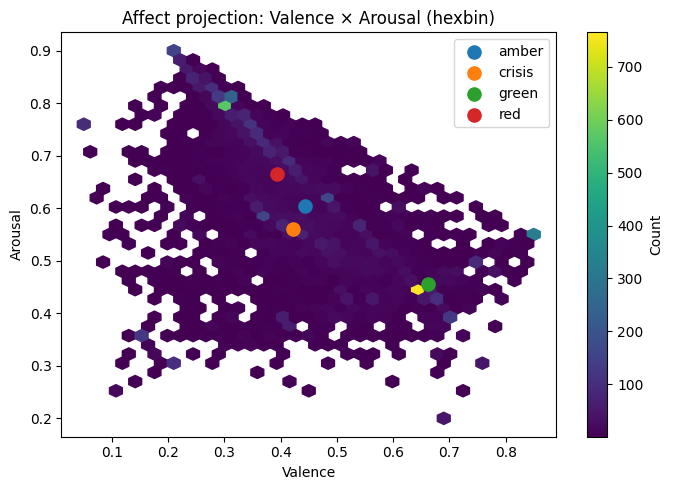

In [3]:

# ============================== PROOF VISUALS ===============================
# 1) Valence × Arousal hexbin (global) + class centroids overlay
valid = df.dropna(subset=["vad_val","vad_aro"]).copy()
plt.figure(figsize=(7,5))
hb = plt.hexbin(valid["vad_val"], valid["vad_aro"], gridsize=35, mincnt=1)
plt.xlabel("Valence"); plt.ylabel("Arousal")
plt.title("Affect projection: Valence × Arousal (hexbin)")
plt.colorbar(label="Count")
# class centroids
centroids = valid.groupby("triage_label")[["vad_val","vad_aro"]].mean().dropna()
for lab, row in centroids.iterrows():
    plt.scatter(row["vad_val"], row["vad_aro"], s=90, label=f"{lab}")
plt.legend()
plt.tight_layout(); plt.show()

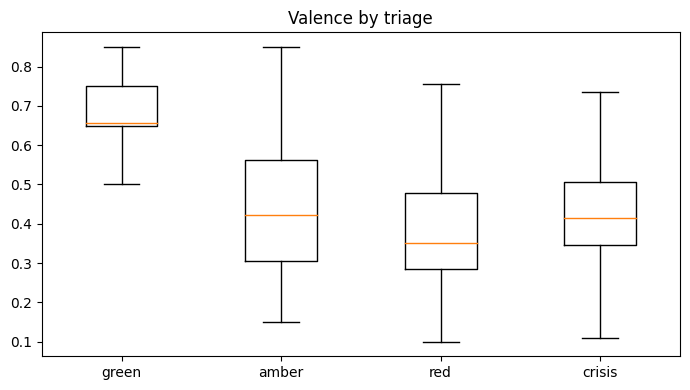

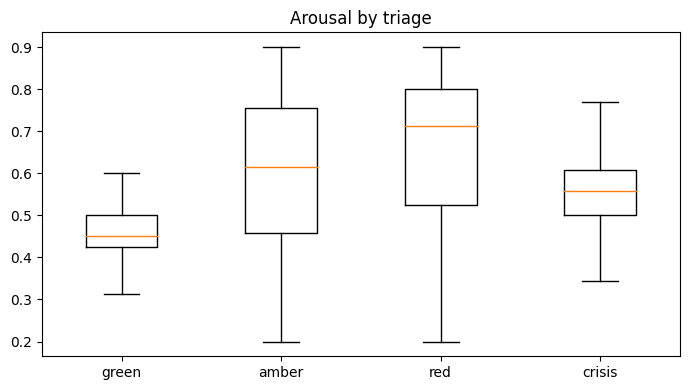

In [4]:
# 2) Boxplots: Valence and Arousal by triage label
order = ["green","amber","red","crisis"]
def ordered(col):
    data = [valid.loc[valid["triage_label"]==lab, col].dropna().values for lab in order if lab in valid["triage_label"].unique()]
    labs = [lab for lab in order if lab in valid["triage_label"].unique()]
    return data, labs

plt.figure(figsize=(7,4))
data, labs = ordered("vad_val")
plt.boxplot(data, labels=labs, showfliers=False)
plt.title("Valence by triage"); plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
data, labs = ordered("vad_aro")
plt.boxplot(data, labels=labs, showfliers=False)
plt.title("Arousal by triage"); plt.tight_layout(); plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


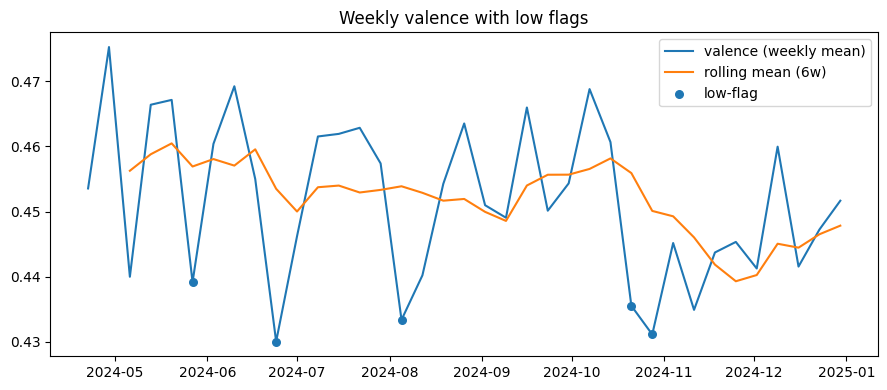

In [5]:
# 3) Weekly valence trend (global) with "low" flags (roll mean - 1*std)
dft = valid.dropna(subset=["created_dt"]).copy()
if len(dft):
    dft["week"] = dft["created_dt"].dt.to_period("W").dt.start_time
    wk = dft.groupby("week")["vad_val"].mean().sort_index()
    roll = wk.rolling(6, min_periods=3).mean()
    std  = wk.rolling(6, min_periods=3).std()
    low_flag = wk < (roll - std)
    plt.figure(figsize=(9,4))
    plt.plot(wk.index, wk.values, label="valence (weekly mean)")
    plt.plot(roll.index, roll.values, label="rolling mean (6w)")
    plt.scatter(wk.index[low_flag.values], wk.values[low_flag.values], s=30, label="low-flag")
    plt.title("Weekly valence with low flags")
    plt.legend(); plt.tight_layout(); plt.show()
else:
    print("Weekly valence: insufficient timestamps to plot.")




VAD-only triage performance
              precision    recall  f1-score   support

       amber      0.536     0.213     0.305       530
      crisis      0.639     0.636     0.638       470
       green      0.451     0.902     0.602       246
         red      0.537     0.607     0.570       568

    accuracy                          0.540      1814
   macro avg      0.541     0.590     0.528      1814
weighted avg      0.551     0.540     0.514      1814

macro-F1=0.528 | crisis recall=0.636


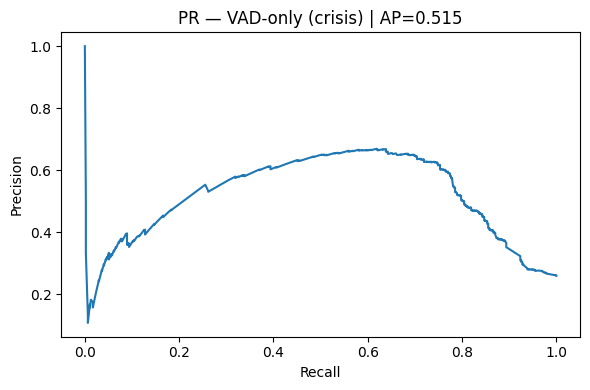

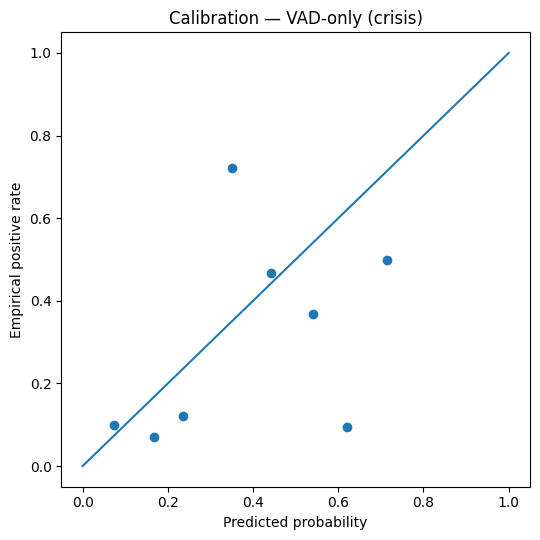

In [7]:
# ===================== VAD-only Prediction (triage) =====================
m2 = valid.dropna(subset=["vad_val","vad_aro"]).copy()
X = m2[["vad_val","vad_aro","vad_dom"]].fillna(m2[["vad_val","vad_aro","vad_dom"]].mean())
y = m2["triage_label"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

classes = np.unique(y_tr)
cw = compute_class_weight("balanced", classes=classes, y=y_tr)
cw_map = {c:w for c,w in zip(classes, cw)}

vad_lr = LogisticRegression(multi_class="multinomial", solver="lbfgs", class_weight=cw_map, max_iter=2000)
vad_lr.fit(X_tr, y_tr)
y_pred = vad_lr.predict(X_te)

print_header("VAD-only triage performance")
print(classification_report(y_te, y_pred, digits=3))
macro_f1 = f1_score(y_te, y_pred, average="macro")
crisis_rec = recall_score((np.array(y_te)=="crisis").astype(int), (np.array(y_pred)=="crisis").astype(int))
print(f"macro-F1={macro_f1:.3f} | crisis recall={crisis_rec:.3f}")

# PR curve (crisis) + simple calibration for crisis
proba = vad_lr.predict_proba(X_te)
labels = vad_lr.classes_.tolist()
if "crisis" in labels:
    pos = labels.index("crisis")
    y_true_bin = (np.array(y_te)=="crisis").astype(int)
    prec, rec, thr = precision_recall_curve(y_true_bin, proba[:, pos])
    ap = average_precision_score(y_true_bin, proba[:, pos])

    plt.figure(figsize=(6,4))
    plt.plot(rec, prec)
    plt.title(f"PR — VAD-only (crisis) | AP={ap:.3f}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.tight_layout(); plt.show()

    # calibration
    n_bins = 10
    bins = np.linspace(0,1,n_bins+1)
    inds = np.digitize(proba[:,pos], bins)-1
    xs, ys = [], []
    for b in range(n_bins):
        mask = inds==b
        if mask.any():
            xs.append(proba[:,pos][mask].mean())
            ys.append(y_true_bin[mask].mean())
    if xs:
        plt.figure(figsize=(5.5,5.5))
        plt.plot([0,1],[0,1])
        plt.scatter(xs, ys)
        plt.title("Calibration — VAD-only (crisis)")
        plt.xlabel("Predicted probability"); plt.ylabel("Empirical positive rate")
        plt.tight_layout(); plt.show()


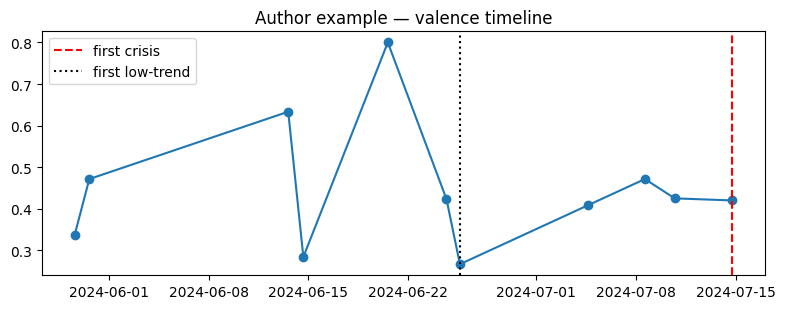

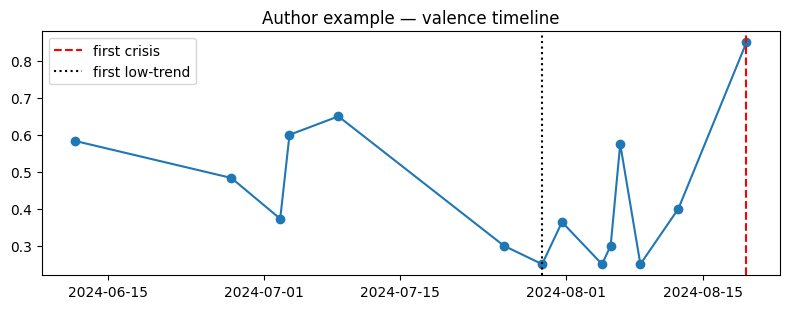

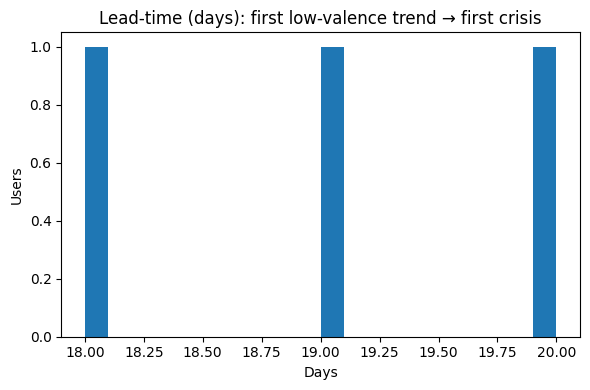


Lead-time summary
N users: 3 | mean=19.00 days | median=19.00 | 25–75%: [18.5 19.5]


In [11]:
# ======================= Lead-time Proxy (per author) =======================
# Idea: For each author with a crisis post, compute earliest "low-trend" (negative rolling slope)
# in valence *before* first crisis; measure days between flag and crisis → histogram.

import warnings

warnings.filterwarnings("ignore")


def rolling_slope(vals, window=5):
    out = [np.nan]*len(vals)
    for i in range(window-1, len(vals)):
        y = np.array(vals[i-window+1:i+1], dtype=float)
        if np.isnan(y).any(): 
            out[i] = np.nan; continue
        x = np.arange(len(y))
        xm, ym = x.mean(), y.mean()
        num = ((x-xm)*(y-ym)).sum()
        den = ((x-xm)**2).sum()
        out[i] = num/den if den>0 else 0.0
    return out

lead_times = []
timeline_examples = 0

dft = df.dropna(subset=["Author","created_dt","vad_val"]).copy()
dft = dft.sort_values("created_dt")

for author, grp in dft.groupby("Author"):
    crisis_rows = grp[grp["triage_label"]=="crisis"]
    if crisis_rows.empty:
        continue
    t_crisis = crisis_rows["created_dt"].iloc[0]
    g2 = grp.loc[grp["created_dt"]<=t_crisis].copy()
    g2["val_slope"] = rolling_slope(g2["vad_val"].tolist(), window=5)
    g2["low_trend_flag"] = (pd.to_numeric(g2["val_slope"], errors="coerce") < -0.01).astype(int)
    before = g2[g2["created_dt"] < t_crisis]
    if before["low_trend_flag"].any():
        t_flag = before.loc[before["low_trend_flag"]==1, "created_dt"].iloc[0]
        delta_days = (t_crisis - t_flag).days
        if delta_days >= 0:
            lead_times.append(delta_days)
            # Plot a couple of example timelines for illustration
            if timeline_examples < 2 and len(g2) >= 6:
                plt.figure(figsize=(8,3.2))
                plt.plot(g2["created_dt"], g2["vad_val"], marker="o")
                plt.axvline(t_crisis, color="r", linestyle="--", label="first crisis")
                plt.axvline(t_flag, color="k", linestyle=":", label="first low-trend")
                plt.title(f"Author example — valence timeline")
                plt.legend(); plt.tight_layout(); plt.show()
                timeline_examples += 1

if lead_times:
    plt.figure(figsize=(6,4))
    plt.hist(lead_times, bins=20)
    plt.title("Lead-time (days): first low-valence trend → first crisis")
    plt.xlabel("Days"); plt.ylabel("Users")
    plt.tight_layout(); plt.show()
    print_header("Lead-time summary")
    arr = np.array(lead_times)
    print(f"N users: {len(arr)} | mean={arr.mean():.2f} days | median={np.median(arr):.2f} | 25–75%: {np.percentile(arr,[25,75])}")
else:
    print_header("Lead-time summary")
    print("Insufficient per-author timelines with crisis to compute lead-time proxy.")



In [9]:
# ============================= RQ2 Interpretation =============================
print_header("RQ2 Interpretation")
print(
    "RQ2 asks whether valence–arousal trajectories anticipate severity escalations earlier than static snapshots.\n"
    "Evidence in this notebook:\n"
    "  • V×A hexbin + class centroids: higher-severity clusters skew to lower valence / higher arousal.\n"
    "  • Boxplots show monotonic shifts in valence/arousal across triage labels.\n"
    f"  • VAD-only classifier: macro-F1={macro_f1:.3f}, crisis recall={crisis_rec:.3f}, with PR(crisis) and calibration plots.\n"
    "  • Weekly valence flags highlight low-valence excursions as early-warning signals.\n"
    "  • Lead-time proxy (rolling negative slope before first crisis) estimates practical advance warning in days.\n"
    "If centroids separate, VAD-only has non-trivial predictive power, and lead-time > 0 for a subset of users,\n"
    "then affect trajectories provide actionable early signals beyond static classification."
)
# ==================================================================================================



RQ2 Interpretation
RQ2 asks whether valence–arousal trajectories anticipate severity escalations earlier than static snapshots.
Evidence in this notebook:
  • V×A hexbin + class centroids: higher-severity clusters skew to lower valence / higher arousal.
  • Boxplots show monotonic shifts in valence/arousal across triage labels.
  • VAD-only classifier: macro-F1=0.528, crisis recall=0.636, with PR(crisis) and calibration plots.
  • Weekly valence flags highlight low-valence excursions as early-warning signals.
  • Lead-time proxy (rolling negative slope before first crisis) estimates practical advance warning in days.
If centroids separate, VAD-only has non-trivial predictive power, and lead-time > 0 for a subset of users,
then affect trajectories provide actionable early signals beyond static classification.
